In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

# DB connection
conn = psycopg2.connect(
    dbname="lundahoj",
    user="postgres",
    password="4268",   # <- your password
    host="localhost",
    port=5432
)


In [2]:
for table in ["stations", "station_readings"]:
    df = pd.read_sql(f"SELECT COUNT(*) AS count FROM {table};", conn)
    print(f"{table}: {df.iloc[0,0]} rows")


stations: 20 rows
station_readings: 180 rows


/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/1728170528.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT COUNT(*) AS count FROM {table};", conn)


In [3]:
stations = pd.read_sql("SELECT * FROM stations LIMIT 5;", conn)
stations



/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/3009321860.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stations = pd.read_sql("SELECT * FROM stations LIMIT 5;", conn)


,station_id,name,city,latitude,longitude,capacity,active,first_seen_utc,last_seen_utc
0,f1a9d2a3e05b9a36f50521f8abc7c648,IDEON NORR,None,55.715504,13.214801,21,True,2025-09-24 08:51:11.811276+00:00,2025-09-25 10:54:47.523500+00:00
1,f4f343dba6ee93a2bde97fdaeda667f4,STORTORGET,None,55.702978,13.193365,21,True,2025-09-24 08:51:11.811276+00:00,2025-09-25 10:54:47.523500+00:00
2,0f4c9329d47b9bf2d40c317d7ad80498,MÅRTENSTORGET,None,55.701911,13.196026,33,True,2025-09-24 08:51:11.811276+00:00,2025-09-25 10:54:47.523500+00:00
3,33ad42a81ab4686112d56258838f80fe,BANTORGET,None,55.704241,13.187612,25,True,2025-09-24 08:51:11.811276+00:00,2025-09-25 10:54:47.523500+00:00
4,3a7cf3adb5b51863f0ad76a84248c5e2,STADSPARKEN NORR,None,55.701373,13.185656,20,True,2025-09-24 08:51:11.811276+00:00,2025-09-25 10:54:47.523500+00:00


In [4]:
readings = pd.read_sql("SELECT * FROM station_readings ORDER BY observed_at_utc DESC LIMIT 5;", conn)
readings


/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/2994014875.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  readings = pd.read_sql("SELECT * FROM station_readings ORDER BY observed_at_utc DESC LIMIT 5;", conn)


,reading_id,station_id,bikes_available,docks_available,percent_full,observed_at_utc,source
0,180,f4f343dba6ee93a2bde97fdaeda667f4,7,14,0.333333,2025-09-25 10:54:47.508110+00:00,citybikes
1,179,f1a9d2a3e05b9a36f50521f8abc7c648,11,10,0.523810,2025-09-25 10:54:47.508110+00:00,citybikes
2,178,edfe34982a63c8ca5f7fee8ef4bdeba8,15,6,0.714286,2025-09-25 10:54:47.508110+00:00,citybikes
3,177,e71ef03e4ccb024ada2d87660b0d8885,6,17,0.260870,2025-09-25 10:54:47.508110+00:00,citybikes
4,176,e70aeeabbc22ee53c517dc2f858c907e,5,13,0.277778,2025-09-25 10:54:47.508110+00:00,citybikes


/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/2198990593.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_station = pd.read_sql(


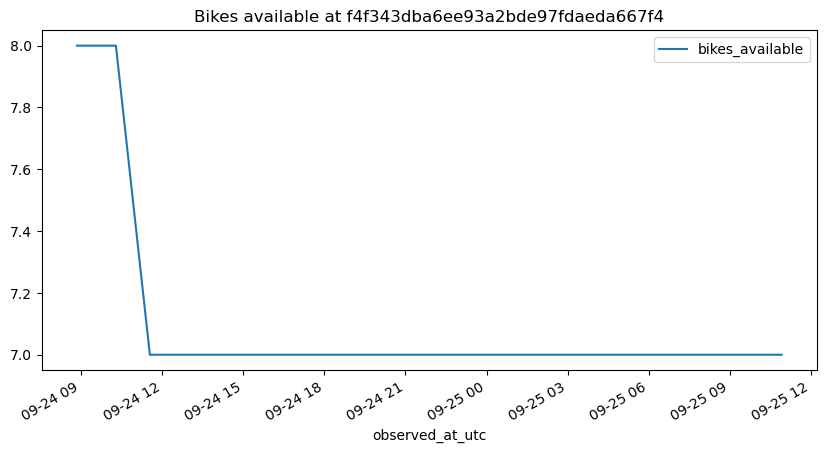

In [5]:
station_id = stations.iloc[1]["station_id"]

df_station = pd.read_sql(
    f"""
    SELECT observed_at_utc, bikes_available, docks_available
    FROM station_readings
    WHERE station_id = '{station_id}'
    ORDER BY observed_at_utc
    """, conn
)

df_station["observed_at_utc"] = pd.to_datetime(df_station["observed_at_utc"])

df_station.plot(x="observed_at_utc", y="bikes_available", figsize=(10,5), title=f"Bikes available at {station_id}")
plt.show()


/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/1621709890.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pct = pd.read_sql(


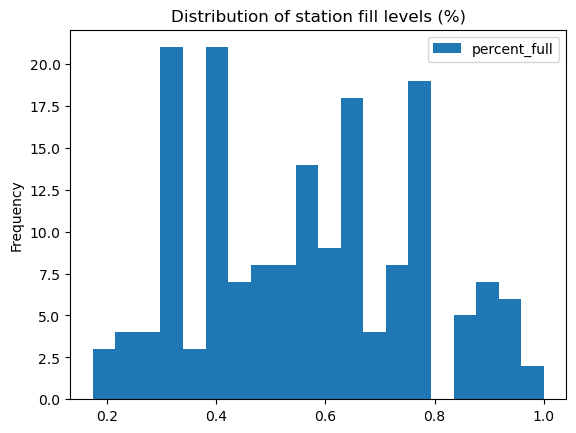

In [6]:
df_pct = pd.read_sql(
    """
    SELECT percent_full
    FROM station_readings
    WHERE percent_full IS NOT NULL
    """, conn
)

df_pct.plot(kind="hist", bins=20, title="Distribution of station fill levels (%)")
plt.show()


In [7]:
df_busy = pd.read_sql(
    """
    SELECT s.name, COUNT(r.reading_id) AS observations
    FROM station_readings r
    JOIN stations s ON r.station_id = s.station_id
    GROUP BY s.name
    ORDER BY observations DESC
    LIMIT 10;
    """, conn
)
df_busy


/var/folders/7g/zfthx6_s33n7jdqw_31_vg980000gn/T/ipykernel_15858/2378726131.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_busy = pd.read_sql(


,name,observations
0,BANTORGET,9
1,FABRIKSGATAN,9
2,VÄSTRA STATIONSTORGET,9
3,IDEON NORR,9
4,TETRA PAK,9
5,STORTORGET,9
6,MÅRTENSTORGET,9
7,RIDHUSET,9
8,PROFESSORSGATAN,9
9,UNIVERSITETSSJUKHUSET,9
